In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

df= pd.read_csv("C:\\Users\\BMT NETWORKS\\OneDrive\\Documents\\Elevo Internship\\Task_4\\kaggle_survey_2017_2021.csv")


In [ ]:
#106302 entries
df.info()

In [ ]:
# 6289 duplicates
all_duplicates= df[df.duplicated(keep=False)]
len(all_duplicates)

In [ ]:
Cleaned_Data = df.copy(deep=False)
id(Cleaned_Data)== id(df)

In [ ]:
Cleaned_Data= Cleaned_Data.drop_duplicates(keep="last")
Cleaned_Data.head(10)

In [ ]:
#101845 rows are left after removing duplicates
rows_missing_value=Cleaned_Data[Cleaned_Data.isna().any(axis=1)]
rows_missing_value

In [ ]:
# after scanning through the dataset.
#  i decided to work with the following columns based on their discrete values; 
# q1,q2,q3,q4,q5,q6,q11,q13, q15, q21,q22, q23, 25,26,,q33, q35 and q45

In [ ]:
# model for handling missing values: If percentage of missing values is
#< 5%: mode for replacing null values in categorical data
#5-30%: replace null values with unknown placeholder
#30-70%:use of indicator column
#>70%: drop column or dont touch

In [9]:
#columns with missing values
column1= Cleaned_Data[Cleaned_Data["Q1"].isna()]
len(column1)

356

In [ ]:
# column Q1 has 356 missing values, 0.35% of the total column, hence use mode for replancement
Cleaned_Data["Q1"] = Cleaned_Data["Q1"].fillna(
    Cleaned_Data["Q1"].mode()[0]
)

In [ ]:
Cleaned_Data["Q1"].isna().sum()

In [ ]:
#handling missing values in q2. It is the gender column and has 62 missing values, 
# 0.06% missing of total coumn
column2= Cleaned_Data["Q2"]
column2.isna().sum()

np.int64(62)

In [15]:
Cleaned_Data["Q2"]= Cleaned_Data["Q2"].fillna(Cleaned_Data["Q2"].mode()[0])

In [16]:
Cleaned_Data["Q2"]= Cleaned_Data["Q2"].fillna(Cleaned_Data["Q2"].mode()[0])

In [ ]:
#handling missing values in q3. The column contains question on country of resisdence. It has
# 81 missing values,0.8%
column3= Cleaned_Data["Q3"]
column3.isna().sum()

In [18]:
Cleaned_Data["Q3"] = Cleaned_Data["Q3"].fillna(Cleaned_Data["Q3"].mode()[0])

In [ ]:
#handling missing values on q4. It has 1839 missing values, 1.8% 
column4= Cleaned_Data["Q4"]
column4.isna().sum()

In [20]:
Cleaned_Data["Q4"]= Cleaned_Data["Q4"].fillna(Cleaned_Data["Q4"].mode()[0])

In [21]:
#handling missing values in Q5. It is the column of title most simlar to your current role
# it has 4915 missing values, 4.8%
Cleaned_Data["Q5"]= Cleaned_Data["Q5"].fillna(Cleaned_Data["Q5"].mode()[0])

In [22]:
#handling missing values in q6. how many years of wriiting code. it has 1181 missing vaues
#12% missing values. use of unknown place holder
Cleaned_Data["Q6"]= Cleaned_Data["Q6"].fillna("Unknown")

In [23]:
Cleaned_Data["Q6"].isna().sum()

np.int64(0)

In [24]:
# handling missing values in q8. It is the column of what programming language will you recommend... 
# It has 17681 missing values, 17%

Cleaned_Data["Q8"]= Cleaned_Data["Q6"].fillna("Unknown")

In [ ]:
Cleaned_Data["Q8"].isna().sum()

In [ ]:
#handle missing values in Q13 by dropping missing values. It is the column containing app. how many times you have used a T....
#it has 46459 missing values
# missing value is q13 is 464459 almost 46% of the whole data entries. I decided to leave it untouch 
# not to be used for analyss
Cleaned_Data["Q13"].isna().sum()


In [252]:
# it has 29044 missing values, 28.5% of the whole column
Cleaned_Data["Q15"].isna().sum()

np.int64(29044)

In [ ]:
# leaving column Q33 and Q35 untounched because they have over 90% missing values
# leaving column Q21, Q22, Q25 and Q41 because of over 50% missing values

In [ ]:
#Data analysis and visualisation

In [35]:
pd.options.display.max_rows = 999

In [ ]:
Cleaned_Data["Q1"].head(150)

In [50]:
Cleaned_Data["Age_Num"] = (
    Cleaned_Data["Q1"]
    .str.replace("+", "", regex=False)   # remove +
    .str.split("-")
    .str[0]
    .convert_dtypes(int)
)


In [ ]:
Cleaned_Data["Age_Num"].astype(int)

In [60]:
del Cleaned_Data["Age_Num"]

In [141]:
age_map = {
    "15-18": "Youth",
    "18-21": "Youth",
    "22-24": "Youth",
    "25-29": "Young Adult",
    "30-34": "Young Adult",
    "35-39": "Adults",
    "40-44": "Adults",
    "45-49": "Middle Age",
    "50-54": "Middle Age",
    "55-59":  "Middle Age",
    "60-64": "Young Old",
    "65-69":"Old",
    "60-69":"Young Old",
    "70+": "Old"
}

Cleaned_Data["Age_Group"] = Cleaned_Data["Q1"].map(age_map)

In [ ]:
#Cleaned_Data["index"]=pd.Index
Cleaned_Data.tail(30)


In [123]:
len(Cleaned_Data) == Cleaned_Data["Age_Group"].count()

np.False_

In [142]:
Cleaned_Data["Age_Group"].count()

np.int64(101845)

In [143]:
Cleaned_Data["Age_Group"].isna().sum()

np.int64(1)

In [ ]:
columnx= Cleaned_Data[Cleaned_Data["Age_Group"].isna()]
columnx.head(10)

In [113]:
Cleaned_Data["Q1"].isna().sum()

np.int64(0)

In [102]:
Cleaned_Data.insert(0, "index", range(1, len(Cleaned_Data) + 1))

In [103]:
pivot2= Cleaned_Data.pivot_table(index="Q1", values="index", aggfunc="count")
pivot2

,index
Q1,
18-21,14595
22-24,18817
25-29,22776
30-34,15433
35-39,10498
40-44,7111
45-49,4866
50-54,3431
55-59,2056


In [158]:
pivot1= Cleaned_Data.pivot_table( index="Age_Group", values="index",  aggfunc="count")
pivot1

,index
Age_Group,
Adults,17609
Middle Age,10353
Old,461
Young Adult,38209
Young Old,1801
Youth,33412


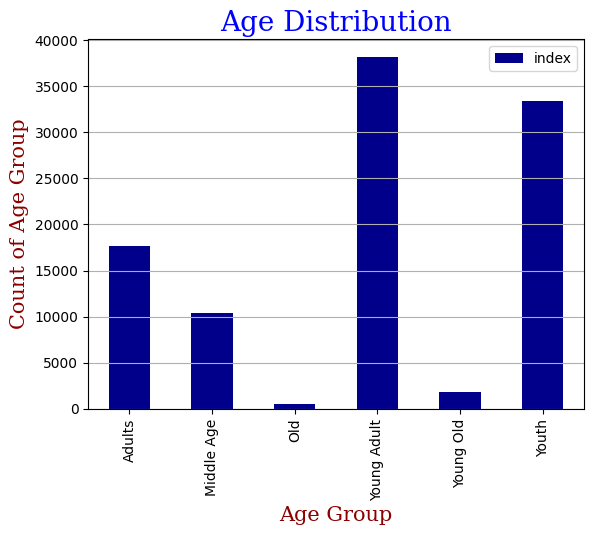

In [264]:

pivot1.plot(kind="bar", color="darkblue")
font1={"font":"serif", "color":"blue", "size":20}
font2={"font":"serif", "color":"darkred", "size":15}
plt.title("Age Distribution", fontdict=font1)
plt.xlabel("Age Group", fontdict=font2)
plt.ylabel("Count of Age Group", fontdict=font2)
plt.grid(axis="y")
plt.show()

In [ ]:
Cleaned_Data["Q2"].head(50)

In [176]:
sex_map={
  "Man":1,
  "Male":1,
  "Woman":1,
  "Female":2,
  "Prefer not to say": 3,
  "Nonbinary": 4,
  "Prefer to self-describe":5
}

Cleaned_Data["Sex_Numeric"]= Cleaned_Data["Q2"].map(sex_map)

In [177]:
Cleaned_Data["Sex_Numeric"].count()

np.int64(101618)

In [178]:
Cleaned_Data["Sex_Numeric"].isna().sum()

np.int64(228)

In [180]:
pivot3= Cleaned_Data.pivot_table(index="Sex_Numeric", values="index",  aggfunc="count" )
pivot3

,index
Sex_Numeric,
1.0,90418
2.0,9560
3.0,1276
4.0,140
5.0,224


In [181]:
sex_group={
    1.0:"Male",
    2.0:"Female",
    3.0:"Prefer not to say",
    4.0: "Nonbinary",
    5.0: "Prefer to self-describe"
}

Cleaned_Data["Sex_Group"] = Cleaned_Data["Sex_Numeric"].map(sex_group)

In [186]:
Cleaned_Data["Sex_Group"].astype(str)

0            NaN
1           Male
2           Male
3           Male
4           Male
           ...  
106297    Female
106298      Male
106299    Female
106300    Female
106301      Male
Name: Sex_Group, Length: 101846, dtype: str

In [ ]:
pivot4= Cleaned_Data.pivot_table(index="Sex_Group", values="index", aggfunc="count")
pivot4

,index
Sex_Group,
Female,9560
Male,90418
Nonbinary,140
Prefer not to say,1276
Prefer to self-describe,224


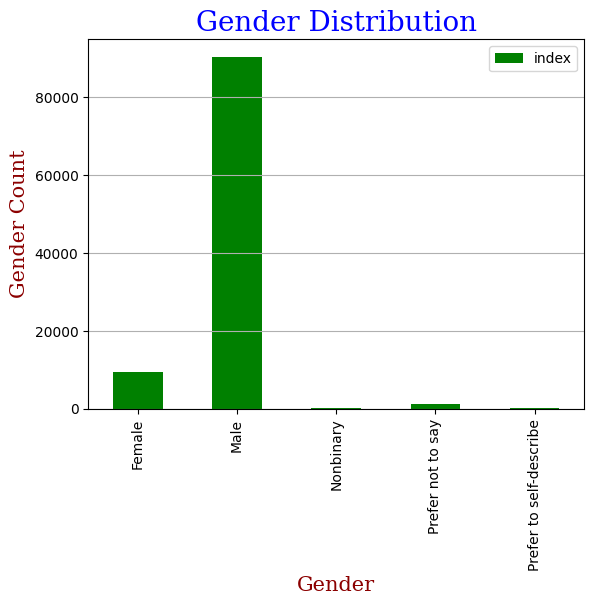

In [221]:

pivot4.plot(kind="bar", color="green")
font1={"font":"serif", "color":"blue", "size":20}
font2={"font":"serif", "color":"darkred", "size":15}
plt.title("Gender Distribution", fontdict=font1)
plt.xlabel("Gender", fontdict=font2)
plt.ylabel("Gender Count", fontdict=font2)
plt.grid(axis="y")
plt.show()

In [256]:
Cleaned_Data["Q4"]

0         What is the highest level of formal education ...
1                                          Bachelors degree
2                                            Masters degree
3                                            Masters degree
4                                           Doctoral degree
                                ...                        
106297                                       Masters degree
106298                                     Bachelors degree
106299                                       Masters degree
106300                               I prefer not to answer
106301    I did not complete any formal education past h...
Name: Q4, Length: 101846, dtype: str

In [210]:
Cleaned_Data["Q4"]= Cleaned_Data["Q4"].str.replace(r"[â€™\']", "", regex=True)
Cleaned_Data["Q4"]

0         What is the highest level of formal education ...
1                                          Bachelors degree
2                                            Masters degree
3                                            Masters degree
4                                           Doctoral degree
                                ...                        
106297                                       Masters degree
106298                                     Bachelors degree
106299                                       Masters degree
106300                               I prefer not to answer
106301    I did not complete any formal education past h...
Name: Q4, Length: 101846, dtype: str

In [216]:
pivot5= Cleaned_Data.pivot_table(index="Education_Group", values="index", aggfunc="count")
pivot5

,index
Education_Group,
Bachelors,33426
Doctoral,13146
Drop out,5284
High School,1122
Masters,44163
Prefer not to answer,1787
Professional degree,2350
Professional doctorate,360


In [215]:
Education_Group={
    "Bachelors degree":"Bachelors",
    "Masters degree":"Masters",
    "Doctoral degree": "Doctoral",
    "I prefer not to answer": "Prefer not to answer",
    "No formal education past high school": "High School",
    "Professional degree": "Professional degree",
    "Professional doctorate":"Professional doctorate",
    "Some college/university study without earning a bachelors degree": "Drop out"

}
Cleaned_Data["Education_Group"]= Cleaned_Data["Q4"]. map(Education_Group)

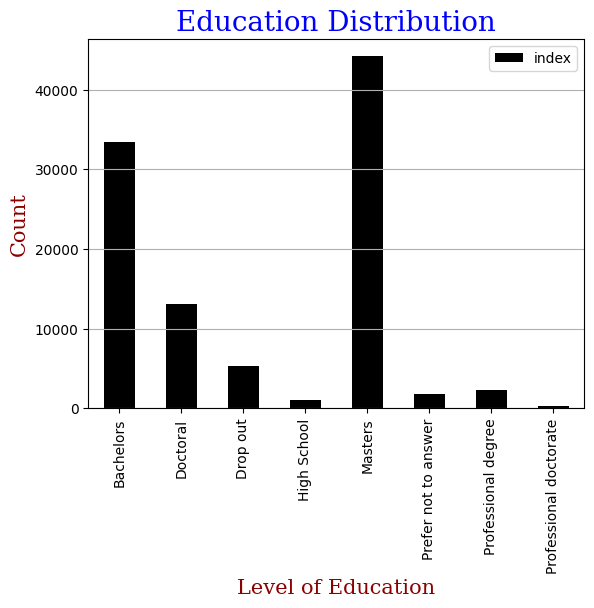

In [269]:

pivot5.plot(kind="bar", color="black")
font1={"font":"serif", "color":"blue", "size":20}
font2={"font":"serif", "color":"darkred", "size":15}
plt.title("Education Distribution", fontdict=font1)
plt.xlabel("Level of Education", fontdict=font2)
plt.ylabel("Count", fontdict=font2)
plt.grid(axis="y")
plt.show()


In [ ]:
Cleaned_Data["Q5"]

In [ ]:
pivot6=Cleaned_Data.pivot_table(index="Q5", values="index", aggfunc="count")
pivot6

In [235]:
Role_Group={
    "Student":"Student",
    "Software Developer/Software Engineer": "Programmers",
    "Software Engineer": "Programmers",
    "Programmer":"Programmers",
    "Computer Scientist":"Programmers",
    "Researcher":"Researchers",
    "Research Assistant":"Researchers",
    "Research Scientist":"Researchers",
    "Operations Research Practitioner": "Researchers",
    "Scientist/Researcher": "Researchers",
    "Salesperson": "Salesperson",
    "Business Analyst":"Analysts",
    "Data Analyst":"Analysts",
    "Market Analyst":"Analysts",
    "Cheif Officer":"Managers",
    "Manager": "Managers",
    "Product Manager": "Managers",
    "Product/Project Manager" : "Managers",
    "Program/Project Manager": "Managers",
    "Currently not employed": "Unemployed",
    "DBA/Database Engineer":"Data Experts",
    "Data Engineer" :"Data Experts",
    "Data Journalist" :"Data Experts",
    "Data Miner" :"Data Experts",
    "Data Scientist":"Data Experts",
    "Predictive Modeler":"Data Experts",
    "Developer Advocate": "Developer Advocates",
    "Developer Relations/Advocacy": "Developer Advocates",
    "Engineer":"Engineer",
    "Machine Learning Engineer":"Data Experts",
    "Statistician": "Statistician"

    
    



}

Cleaned_Data["Role_Group"] = Cleaned_Data["Q5"].map(Role_Group)
Cleaned_Data["Role_Group"]

0                 NaN
1                 NaN
2            Managers
3         Programmers
4         Researchers
             ...     
106297        Student
106298    Programmers
106299        Student
106300        Student
106301    Programmers
Name: Role_Group, Length: 101846, dtype: str

In [236]:
pivot7=Cleaned_Data.pivot_table(index="Role_Group", values="index", aggfunc="count")
pivot7


,index
Role_Group,
Analysts,12280
Data Experts,22821
Developer Advocates,216
Engineer,497
Managers,3601
Programmers,12343
Researchers,7402
Salesperson,102
Statistician,1428


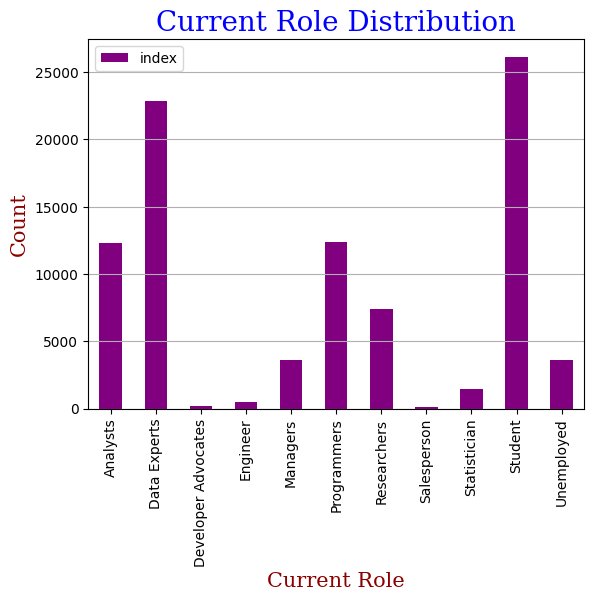

In [261]:
pivot7.plot(kind="bar", color="purple")
ont1={"font":"serif", "color":"blue", "size":20}
font2={"font":"serif", "color":"darkred", "size":15}
plt.title("Current Role Distribution", fontdict=font1)
plt.xlabel("Current Role", fontdict=font2)
plt.ylabel("Count", fontdict=font2)
plt.grid(axis="y")
plt.show()

In [243]:
Cleaned_Data["Q6"].head(20)

0     For how many years have you been writing code ...
1                                            5-10 years
2                                             20+ years
3                                             1-3 years
4                                             20+ years
5                                             < 1 years
6                                             < 1 years
7                                             1-3 years
8                                            5-10 years
9                                             3-5 years
10                                            1-3 years
11                                            1-3 years
12                                            < 1 years
13                                            < 1 years
14                                           5-10 years
15                                            < 1 years
16                                          10-20 years
17                                            20

In [ ]:
Code_level={
    "I have never written code": "Novice",
   "< 1 years": "Beginner",
    "1-3 years": "Beginner",
    "3-5 years": "Intermediate",
    "5-10 years": "Advanced",
    "10-20 years": "Expert",
    "20+ years":"Ultimate"



}

Cleaned_Data["Code_Group"]= Cleaned_Data["Q6"].map(Code_level)
Cleaned_Data["Code_Group"]

In [247]:
pivot8=Cleaned_Data.pivot_table(index="Code_Group", values="index", aggfunc="count")
pivot8

,index
Code_Group,
Advanced,9683
Beginner,20896
Expert,6064
Intermediate,15995
Novice,3021
Ultimate,3765


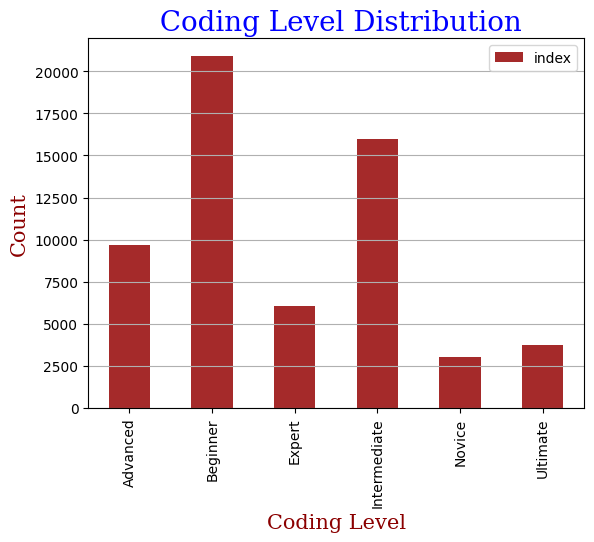

In [248]:
pivot8.plot(kind="bar", color="brown")
ont1={"font":"serif", "color":"blue", "size":20}
font2={"font":"serif", "color":"darkred", "size":15}
plt.title(" Coding Level Distribution", fontdict=font1)
plt.xlabel("Coding Level", fontdict=font2)
plt.ylabel("Count", fontdict=font2)
plt.grid(axis="y")
plt.show()

In [259]:
Cleaned_Data["Q15"]

0         For how many years have you used machine learn...
1                                                5-10 years
2                                              Under 1 year
3                     I do not use machine learning methods
4                                                5-10 years
                                ...                        
106297                                                  NaN
106298                                                  NaN
106299                                                  NaN
106300                                                  NaN
106301                                                  NaN
Name: Q15, Length: 101846, dtype: str